This Notebook provides an example of the MaskedDiffusionLanguageModel's ability to model some elementary data.

In [21]:
using Diffusions, Random, StatsBase, Flux, OneHotArrays, Distributions, Plots, Random, StatsPlots, LaTeXStrings
include("diffusion.jl")
include("loss.jl")
include("Diffusions.jl/src/maskedarrays.jl")
rng = Random.default_rng()

TaskLocalRNG()

In [9]:
# This function runs into errors due to the Process type defined in Diffusions.jl
# Therefore, it is called here once again to resolve this error
# This problem will disappear when the MaskedDiffusionLanguageModels are integrated into the package

import Diffusions: sampleforward

function sampleforward(rng::AbstractRNG, process::Process, t::Real, x::AbstractArray)
    x = copy(x)
    maskedvec(x) .= _sampleforward(rng, process, t, maskedvec(x))
    return x
end

function sampleforward(rng::AbstractRNG, process::Process, t::AbstractVector{<:Real}, x::AbstractArray)
    x = copy(x)
    for i in axes(x, ndims(x))
        maskedvec(x, i) .= _sampleforward(rng, process, t[i], maskedvec(x, i))
    end
    return x
end


sampleforward (generic function with 6 methods)

In [15]:
# These functions run into the same problems as the ones mentioned above

import Diffusions: samplebackward

function checktimesteps(timesteps)
    length(timesteps) ≥ 2 || throw(ArgumentError("timesteps must have at least two timesteps"))
    issorted(timesteps) || throw(ArgumentError("timesteps must be increasing"))
    all(>(0), timesteps) || throw(ArgumentError("all timesteps must be positive"))
end

struct NullTracker end

track!(::NullTracker, t, x, x0) = nothing


struct Tracker
    time::Vector
    data::Vector
    x0::Vector
end

Tracker() = Tracker([], [], [])

function track!(tracker::Tracker, t, x, x0)
    push!(tracker.time, t)
    push!(tracker.data, x)
    push!(tracker.x0, x0)
    return nothing
end


function samplebackward(rng::AbstractRNG, guess, process, timesteps, x; tracker=NullTracker())
    checktimesteps(timesteps)
    i = lastindex(timesteps)
    t = timesteps[i]
    while i > firstindex(timesteps)
        s = timesteps[i-1]
        x_0 = guess(x, t)
        x = endpoint_conditioned_sample(rng, process, s, t, x_0, x)
        # @show x
        # track!(tracker, s, x, x_0)
        t = s
        i -= 1
    end
    return x
end

samplebackward (generic function with 2 methods)

In [16]:
function endpoint_conditioned_sample(rng::AbstractRNG, process::Process, s::Real, t::Real, x_0::AbstractArray, x_t::AbstractArray)
    if x_t isa MaskedArray
        # x_0 inherits masked elements from x_t
        x_0 = MaskedArray(x_0, x_t.indices)
    end
    x = copy(x_t)
    maskedvec(x) .= _endpoint_conditioned_sample(rng, process, s, t, maskedvec(x_0), maskedvec(x_t))
    return x
end

endpoint_conditioned_sample(rng::AbstractRNG, process, s::Real, t::Real, x_0, x_t) =
    endpoint_conditioned_sample.(rng, process, s, t, x_0, x_t)

# sample x at time s conditioned on x_0 at time 0 and x_t at time t
endpoint_conditioned_sample(P::Process, s::Real, t::Real, x_0, x_t) = endpoint_conditioned_sample(Random.default_rng(), P, s, t, x_0, x_t)


endpoint_conditioned_sample (generic function with 3 methods)

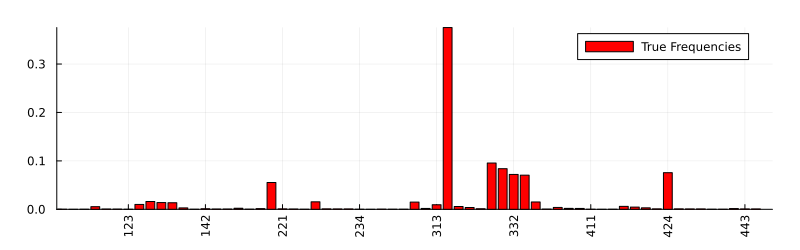

In [10]:
#Setting up a toy Markov sequence generator
S = [0.06591801058555521, 0.07969206822877058, 0.7577065839917972, 0.09668333719387696]
M1 = [0.08846562872099392 0.16990851783433247 0.7057593661240716 0.035866487320601916; 0.7431475939699389 0.21587009667771628 0.03183492266912633 0.009147386683218569; 0.5299436666548881 0.14037279287634963 0.31880667650890665 0.010876863959855763; 0.06768187476034546 0.8712803961334261 0.026959057317955764 0.03407867178827272]
M2 = [0.03711853694508748 0.004654670142378095 0.02356516471832978 0.9346616281942046; 0.05468190341435613 0.035849693778767566 0.010983526474084716 0.8984848763327916; 0.34718976966999127 0.29844003126407787 0.29174999882526814 0.06262020024066273; 0.06343354243884528 0.46980429610053 0.23584821143715762 0.23091395002346707]


#=
#If you wanted to draw the seq gen randomly
S = exp.(randn(4) .* 1.5)
S ./= sum(S)

M1 = exp.(randn(4,4) .* 1.5)
M1 ./= sum(M1 , dims = 2)

M2 = exp.(randn(4,4) .* 1.5)
M2 ./= sum(M2 , dims = 2)
=#


function target_sample(;S = S, M1 = M1, M2 = M2)
    a = rand(Categorical(S))
    b = rand(Categorical(M1[a,:]))
    c = rand(Categorical(M2[b,:]))
    return [a,b,c]
end

seq_matrix = hcat([[k,j,i] for i in 1:4, j in 1:4, k in 1:4]...)
all_seqs = [seq_matrix[:,i] for i in 1:size(seq_matrix,2)];
prob_seq(seq,S,M1,M2) = S[seq[1]]*M1[seq[1],seq[2]]*M2[seq[2],seq[3]]
all_probs = prob_seq.(all_seqs,Ref(S),Ref(M1),Ref(M2));

bar([join(string.(a)) for a in all_seqs], all_probs,
    xrotation = 90, size = (800,250), label = "True Frequencies",
    color = "red", margins = 0.5Plots.cm, xlim = (0,65))

In [11]:
#Setting up the model
alph = 5 #number of characters
hidden_size = 64

#We encode T with a non-trainable random projection
rff = RandomFourierFeatures(hidden_size, 1.0f0)

#A simple model that takes the full noised sequence and T,
#and returns the logits for each variable in the sequence
embed = Chain(Dense(15,hidden_size,leakyrelu),Dense(hidden_size,hidden_size,leakyrelu))
decode = Chain(
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size÷2),LayerNorm(hidden_size÷2),leakyrelu,
    Dense(hidden_size÷2, 15)
)
model(x,T) = reshape(
    decode(
        embed(
            reshape(x,(15,size(x)[end]))
             ) .+ rff(log(T))
           ),
    (5,3,size(x)[end]));

In [12]:
#Setting up the timestep schedule
timesteps = timeschedule(exp, Float32(0.001),Float32(1.0),100)

#Define the discrete diffusion process
# P = UniformDiscreteDiffusion(1.0,alph)
P = MaskedDiffusionLanguageModel(alph, 5, cosineschedule)

batch_size = 8
ps = Flux.params(embed, decode)
opt = Flux.Optimiser(WeightDecay(0.0001), Adam(0.0001))#Adam(0.001))
cumu_loss = 0.0
training_losses = Float64[];

In [13]:
import Diffusions: eq_dist
eq_dist(model::MaskedDiffusionLanguageModel) = Categorical(model.vocab_size)

eq_dist (generic function with 5 methods)

In [17]:
function _sampleforward(rng::AbstractRNG, process::MaskedDiffusionLanguageModel, t::Real, x::AbstractVector{Bool})
    # Get the keep probability
    α_t = process.α(t)[1]  # Extract the first element of the tuple
    p_keep = α_t  # Assuming α_t directly gives the keep probability
    
    vocab_size = process.vocab_size  # Assume this is a field in your MaskedDiffusionLanguageModel
    num_tokens = length(x) ÷ vocab_size
    
    result = falses(length(x))
    
    for i in 1:num_tokens
        token_slice = (i-1)*vocab_size + 1 : i*vocab_size
        if rand(rng) < p_keep
            # Keep the original token
            result[token_slice] = x[token_slice]
        else
            # Mask the token
            result[token_slice[process.mask_token_id]] = true
        end
    end
    
    return result
end

function _sampleforward(rng::AbstractRNG, process::MaskedDiffusionLanguageModel, t::Real, x::AbstractArray{Bool, 3})
    vocab_size, batch_size, seq_length = size(x)
    
    # Get the keep probability
    α_t = process.α(t)[1]  # Extract the first element of the tuple
    p_keep = α_t  # Assuming α_t directly gives the keep probability
    
    result = falses(size(x))
    
    for k in 1:seq_length
        for j in 1:batch_size
            if rand(rng) < p_keep
                # Keep the original token
                result[:, j, k] = x[:, j, k]
            else
                # Mask the token
                result[process.mask_token_id, j, k] = true
            end
        end
    end
    
    return result
end

_sampleforward (generic function with 3 methods)

In [18]:
#Since this IndependentDiscreteDiffusion process is equivalent, the model from above should be "pre-trained"
#let's check if the loss resumes from where it left off
for iter in 1:50000000
    x = hcat([target_sample() for i in 1:batch_size]...)
    datOH = onehotbatch(x, 1:alph)

    T = rand(timesteps)    

    # @show _sampleforward(rng, P, T, datOH)

    # @show sampleforward(P, T, datOH)

    # @show datOH
    
    # throw(Exception)

    a = P.α(T)

    scal = a[2]/(1-a[2]) 

    diffusedOH = sampleforward(P, T, datOH) #Note, we diffuse the one-hots

    @show -Flux.logitcrossentropy(model(diffusedOH,T), datOH)
    @show T
    # scal = sqrt(1 - exp(-T))
    l,gs = Flux.withgradient(ps) do
        -Flux.logitcrossentropy(model(diffusedOH,T), datOH)*scal
        # -standardloss(P, T, model(diffusedOH,T), datOH)[1]
    end
    Flux.Optimise.update!(opt, ps, gs)
    cumu_loss += l 
    if mod(iter,100) == 0
        opt[2].eta = opt[2].eta * 0.997
        push!(training_losses, cumu_loss/100)
        cumu_loss = 0.0
        IJulia.clear_output(true)
        plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none) |> IJulia.display
        sleep(0.01)
    end
end
IJulia.clear_output(true)
plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none)

-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -1.64824f0
T = 0.024770763f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -1.4134799f0
T = 0.005336698f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -1.7573986f0
T = 0.0014174739f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -1.473404f0
T = 0.030538557f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -1.398784f0
T = 0.21544348f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -1.6256129f0
T = 0.001747528f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -1.7438887f0
T = 0.0123284655f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -1.7409081f0
T = 0.75646335f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -1.8218489f0
T = 0.001747528f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -1.7294201f0
T = 0.099999994f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -1.7204951f0
T = 0.1417474f0
-(Flux.logitcrossentropy(model(diffuse

UndefVarError: UndefVarError: `IJulia` not defined

In [22]:
function zero_sample(x_t, t)
    vocab_size, seq_length, batch_size = size(x_t)
    sm = softmax(model(x_t, t))
    sampled = zeros(Bool, size(x_t))
    for b in 1:batch_size
        for s in 1:seq_length
            probs = sm[:, s, b]
            sampled_token = randcat(rng, probs)
            sampled[:, s, b] = onehotbatch([sampled_token], 1:vocab_size)
        end
    end
    return sampled
end

eq = Categorical(ones(alph)./alph)
N = 10000
seq_length = 3

# Initialize x_T with mask tokens
x_T = falses(alph, seq_length, N)
x_T[5, :, :] .= true  # Assuming 5 is the mask token index

@time samp = samplebackward(zero_sample, P, timesteps, x_T)

# Convert the result to the desired format
diff_samples = [onecold(samp[:, :, i], 1:alph) for i in 1:N]

  5.118567 seconds (28.02 M allocations: 7.786 GiB, 16.68% gc time, 2.86% compilation time: 80% of which was recompilation)


10000-element Vector{Vector{Int64}}:
 [2, 2, 4]
 [2, 2, 2]
 [4, 2, 2]
 [1, 3, 3]
 [2, 3, 4]
 [3, 2, 4]
 [2, 2, 3]
 [1, 3, 4]
 [3, 1, 4]
 [4, 1, 4]
 ⋮
 [4, 4, 4]
 [2, 1, 1]
 [3, 3, 4]
 [2, 1, 2]
 [3, 4, 2]
 [3, 2, 4]
 [2, 3, 2]
 [1, 3, 4]
 [4, 4, 1]

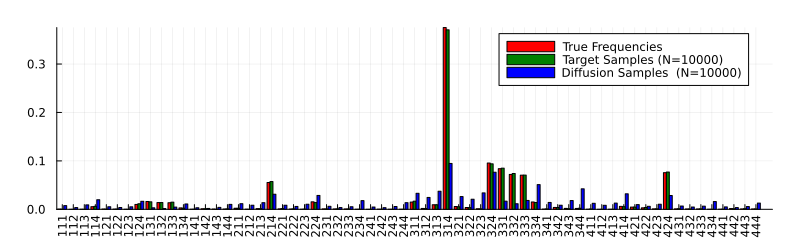

In [23]:
target_samples = [target_sample() for i in 1:N];
prop_d = proportionmap(diff_samples)
target_d = proportionmap(target_samples)
diff_freqs = [get(prop_d,a,0.0) for a in all_seqs]
target_freqs = [get(target_d,a,0.0) for a in all_seqs]

pl = groupedbar([join(string.(a)) for a in all_seqs], [all_probs target_freqs diff_freqs],
    xrotation = 90, size = (800,250), label = ["True Frequencies" "Target Samples (N=$(N))" "Diffusion Samples  (N=$(N))"],
    color = ["red" "Green" "blue"], margins = 0.5Plots.cm, xlim = (0,65))
savefig(pl,"discrete_diff_fluxIJ.pdf")
pl